# 7〜8章で使用するサンプルデータの作成

7〜8章で使用する、入出力があるデータを模擬したデータセット（本文中で「サンプルデータ」と呼んでいるトイデータ）の作成用スクリプトを解説します。

このデータセットは、以下の図に示す中古車価格を想定しています。

![fig7_4.png](https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/images/fig7_4.png)

対象となる中古車の価格は、以下の条件で決まるものとします。

- 価格は平均値$\eta$を中心に分散$\sigma_p^2$の正規分布に従ってばらつく
- 販売店$g$ごとに価格差$r_g$が生じ、この$r_g$は正規分布$\mathcal{N}(0,\sigma_g^2)$に従う
- 価格の平均値$\eta$は、経過年数$x$、総走行距離$o$、車種$k$に依存する切片$w_0[k]$、販売店ごとの価格差$r_g$の線形結合$w_1x + w_2o + w_0[k] + r_g[g]$で表される
- 総走行距離$o$は、経過年数$x$と年間走行距離$d$の積$o=dx$で与えられる
- 年間走行距離$d$は、車種に依存するパラメータ$\mu_d[k]$と依存しないパラメータ$\sigma_d$を持つ対数正規分布$\Lambda(\mu_d[k],\sigma_d)$に従う

これは実際の中古車価格を完全に再現するものではなく、あくまで解説用にシンプル化したモデルです。関係式をまとめると以下のようになります。

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
&d \sim \Lambda(\mu_d[k],\sigma_d) \\
&o=dx \\
&r_g \sim \mathcal{N}(0,\sigma_g) \\
&\eta=w_1x + w_2o + w_0[k] + r_g[g] \\
&p(y \mid \boldsymbol{x}, \boldsymbol{\theta})=\mathcal{N}(\eta,\sigma_p^2)
\end{align}
" />

この生成過程をグラフィカルモデルで表すと、以下の図のようになります。

![fig7_6.png](https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/images/fig7_6.png)

これらの前提に基づき、正常データ1500件、異常データ150件（正常データよりも100万円高い平均値を持つデータを75件、100万円低い平均値を持つデータを75件）生成し、それぞれ2/3を学習用、1/3を推論用に分割します。

次に示すコードで、上記前提に則ったデータセットを生成する関数を記述します。

In [1]:
# コード7.1 7〜8 章で使用するサンプルデータの作成用関数
import numpy as np
import pandas as pd
from scipy import stats

###### データ生成用関数######
def generate_usedcar_data(
    intercept, b_models, b_year, b_odometer, sigma_p, sigma_g,
    mu_distances, s_distance,
    sample_size, random_state
):
    ### 説明変数の生成###
    # 車種（各車種1/3ずつ）
    size_model = int(sample_size / 3)
    x_model = np.concatenate([np.full(size_model, 0),
                               np.full(size_model, 1),
                               np.full(sample_size - size_model*2, 2)])
    # ordinal encoding前の車種名
    model_list = ['sedan', 'compact', 'suv']
    model_names = np.vectorize(lambda x: model_list[x])(x_model)
    # 経過年数（1〜10年の整数を一様分布から生成）
    x_year = stats.randint.rvs(low=1, high=11,
                                size=sample_size, random_state=random_state)
    # 年間走行距離（対数正規分布から生成）
    scales = np.vectorize(lambda x: np.exp(mu_distances[x]))(x_model)
    distance_per_year = stats.lognorm.rvs(
        s=s_distance, scale=scales,
        size=sample_size, random_state=random_state)
    # 走行距離（経過年数× 年間走行距離）
    x_odometer = x_year * distance_per_year
    # 販売店（インデックスを25で割った余りから計算）
    dealers = np.array([i % 25 for i in range(sample_size)])
    ### 応答変数の生成###
    # 販売店ごとの差（グループ差）
    r_g = stats.norm.rvs(loc=0, scale=sigma_g, size=25, random_state=random_state)
    # 価格の平均値
    mu_prices = intercept \
               + np.vectorize(lambda x: b_models[x])(x_model) \
               + x_year*b_year \
               + x_odometer*b_odometer \
               + np.vectorize(lambda x: r_g[x])(dealers)
    # 正規分布から価格を生成（対数正規分布と乱数シードを変える）
    prices = mu_prices + stats.norm.rvs(
        loc=0, scale=sigma_p,
        size=sample_size, random_state=random_state+2)
    # pandas.DataFrameにまとめる
    df = pd.DataFrame({'model_name': model_names, 'year': x_year,
                       'odometer': x_odometer,
                       'dealer': np.vectorize(lambda x: f'dealer{x}')(dealers),
                       'price': prices})
    return df

この関数を用いて、以下のコードでサンプルデータを生成し、printで表示します。

In [2]:
# コード7.2 7〜8章で使用するサンプルデータの作成
from sklearn.model_selection import train_test_split

###### 正常モデルのパラメータ######
intercept_norm = 400 # 切片w_0 [万円]
b_models_norm = [0, -50.0, 100.0] # 各車種の係数w_d[i] [万円]
b_year_norm = -10.0 # 経過年数の比例係数w_1 [万円/年]
b_odometer_norm = -5.0 # 走行距離の比例係数w_2 [万円/万km]
sigma_price_norm = 20 # 個々の車のばらつき（標準偏差）σ_i [万円]
sigma_dealer_norm = 15 # 販売店ごとのばらつき（標準偏差）σ_g [万円]
# 年間走行距離生成用の対数正規分布パラメータ
mu_distances_norm = [-0.5, -1.0, 0] # 対数正規分布のパラメータμ（車種ごとに異なる）
s_distance_norm = 0.2 # 対数正規分布のパラメータσ（exp(μ+σ^2/2)が期待値）

###### データの生成######
# 正常データ生成
df_normal = generate_usedcar_data(
intercept_norm, b_models_norm, b_year_norm, b_odometer_norm, sigma_price_norm,
    sigma_dealer_norm,
    mu_distances_norm, s_distance_norm,
    sample_size=1500, random_state=42)
# 異常データ生成（正常データよりも100万円高い平均値）
df_anomaly_upper = generate_usedcar_data(
    intercept_norm + 100, b_models_norm, b_year_norm, b_odometer_norm,
    sigma_price_norm, sigma_dealer_norm,
    mu_distances_norm, s_distance_norm,
    sample_size=75, random_state=42)
# 異常データ生成（正常データよりも100万円安い平均値）
df_anomaly_lower = generate_usedcar_data(
    intercept_norm - 100, b_models_norm, b_year_norm, b_odometer_norm,
    sigma_price_norm, sigma_dealer_norm,
    mu_distances_norm, s_distance_norm,
    sample_size=75, random_state=42)
df_anomaly = pd.concat([df_anomaly_upper, df_anomaly_lower], axis=0)
# 正常データと異常データにラベルを付ける
df_normal['label'] = 'normal'
df_anomaly['label'] = 'anomaly'
# 学習データと推論データに分ける（2/3が学習用、1/3が推論用）
df_norm_train, df_norm_inference = train_test_split(df_normal, train_size=2/3,
                                                    random_state=42)
df_anom_train, df_anom_inference = train_test_split(df_anomaly, train_size=2/3,
                                                    random_state=42)
# 正常データと異常データを合体させる
df_train = pd.concat([df_norm_train, df_anom_train], axis=0)
df_train = df_train.reset_index(drop=True)
df_inference = pd.concat([df_norm_inference, df_anom_inference], axis=0)
df_inference = df_inference.reset_index(drop=True)
# 作成したデータセットをCSVとして保存
df_train.to_csv('./datasets/usedcar_dataset_train.csv', index=False)
df_inference.to_csv('./datasets/usedcar_dataset_inference.csv', index=False)
# 作成した学習用データセットの情報を表示
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   model_name  1100 non-null   object 
 1   year        1100 non-null   int64  
 2   odometer    1100 non-null   float64
 3   dealer      1100 non-null   object 
 4   price       1100 non-null   float64
 5   label       1100 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 51.7+ KB


### 乱数シードに関する注意

補足として、SciPyの確率分布に従う乱数生成メソッド（`stats.norm.rvs`や`stats.lognorm.rvs`）で乱数を生成する際に、複数の分布に同じ乱数シードを与えると、意図せぬ相関が生じることがあります。

以下の実装例では、同じ乱数シードを使用した場合と異なる乱数シードを使用した場合とで、対数正規分布と正規分布からそれぞれ生成した1000個の乱数を散布図でプロットします。

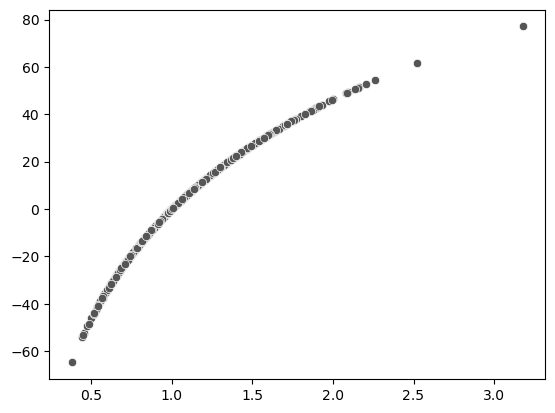

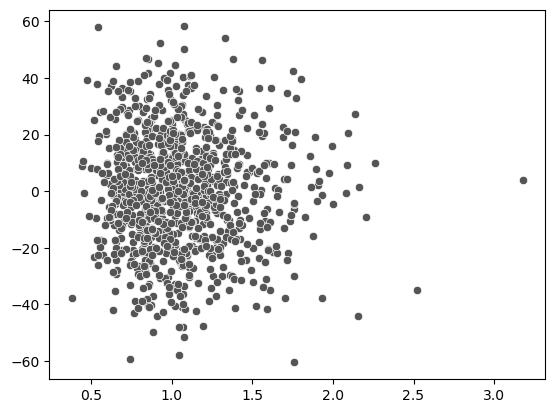

In [3]:
# コード7.3 同じ乱数シードを使用した場合の確率変数同士の相関の発生
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_lognorm_norm_rvs(lognorm_seed, norm_seed):
    lognorm_rvs = stats.lognorm.rvs(
        s=0.3, scale=np.exp(0),
        size=1000, random_state=lognorm_seed)
    norm_rvs = stats.norm.rvs(
        loc=0, scale=20,
        size=1000, random_state=norm_seed)
    sns.scatterplot(x=lognorm_rvs, y=norm_rvs, c='#555555')
    plt.show()

plot_lognorm_norm_rvs(42, 42) # 同じ乱数シード
plot_lognorm_norm_rvs(42, 43) # 異なる乱数シード

同じ乱数シードを使用した場合は対数正規分布と正規分布から生成した確率変数に相関がありますが、異なる乱数シードを使用すると無相関の独立な値を生成できていることがわかります。このような意図しない相関を防ぐために、階層モデルのように複数の確率分布を組み合わせる場合は、分布ごとに異なるシードを設定することが望ましいです。